# Calories Burned Prediction Model

This notebook prepares the data, trains a linear regression model, and evaluates how accurately calories burned can be predicted.

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/raw/gym_members_exercise_tracking.csv')

print(df.head)

<bound method NDFrame.head of      Age  Gender  Weight (kg)  Height (m)  Max_BPM  Avg_BPM  Resting_BPM  \
0     56    Male         88.3        1.71      180      157           60   
1     46  Female         74.9        1.53      179      151           66   
2     32  Female         68.1        1.66      167      122           54   
3     25    Male         53.2        1.70      190      164           56   
4     38    Male         46.1        1.79      188      158           68   
..   ...     ...          ...         ...      ...      ...          ...   
968   24    Male         87.1        1.74      187      158           67   
969   25    Male         66.6        1.61      184      166           56   
970   59  Female         60.4        1.76      194      120           53   
971   32    Male        126.4        1.83      198      146           62   
972   46    Male         88.7        1.63      166      146           66   

     Session_Duration (hours)  Calories_Burned Workout_Ty

## Define Features and Target

The input features contain personal and workout-related information.

The target variable is `Calories_Burned`.

In [17]:
X = df.drop(columns=['Calories_Burned'])
Y = df['Calories_Burned']


print('Feature data shpe:', X.shape)
print('Target data shape:', Y.shape)

Feature data shpe: (973, 14)
Target data shape: (973,)


## Identify Numerical and Categorical Features

The input data contains both numerical and categorical features.

Numerical features contain number values, such as age, weight, heart rate, and session duration.

Categorical features contain text values, such as gender and workout type.

These two feature types must be identified separately because they require different preprocessing steps before model training:

- Numerical features will be standardized.
- Categorical features will be converted into numerical format using one-hot encoding.

In [18]:
categorical_columns= X.select_dtypes(include=['object', 'string']).columns.tolist()
numerical_columns= X.select_dtypes(include=['number']).columns.tolist()

print('Categorical columns:')
print(categorical_columns)

print('\nNumerical columns:')
print(numerical_columns)

Categorical columns:
['Gender', 'Workout_Type']

Numerical columns:
['Age', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'BMI']


## Split the Data

The dataset is divided into training data and test data. The model learns from the training data and is evaluated on the test data.

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size= 0.2,
    random_state= 42
)

print('Training features shape:', X_train.shape)
print('Test features shape:', X_test.shape)
print('Training Target shape:', y_train.shape)
print('Test Target shape', y_test.shape )

print(y_train.head())


Training features shape: (778, 14)
Test features shape: (195, 14)
Training Target shape: (778,)
Test Target shape (195,)
967    1035.0
365     768.0
559     672.0
33      816.0
31      654.0
Name: Calories_Burned, dtype: float64


## Prepare the Features

Numerical features are standardized, while categorical features are converted into numerical columns using one-hot encoding.

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer( transformers= [
    ('numerical', StandardScaler(), numerical_columns),
    ('categorical', OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_columns)

])

print('The preprocessing pipline is ready')



The preprocessing pipline is ready


## Linear Regression Model

This model uses the input features to learn a linear relationship with calories burned.

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

linear_model = Pipeline (
    steps=[ ('data_preparing', preprocessor),
           ('model', LinearRegression())
 ]
)

linear_model.fit(X_train, y_train)
linear_predictions = linear_model.predict(X_test)

# Average absolute prediction error
linear_mae = mean_absolute_error(y_test, linear_predictions)

# Prediction error with larger errors penalized more
linear_rmse= mean_squared_error(y_test, linear_predictions) ** 0.5

# How much of the target variation is explained by the model
linear_r2= r2_score(y_test, linear_predictions)


print('MAE: Average absolute difference between actual and predicted calories')
print('Linear Regression MAE:', linear_mae)


print('\nRMSE: Similar to MAE, but gives more weight to larger errors')
print('Linear Regression RMSE:', linear_rmse)


print('\nR²: Proportion of variation in calories explained by the model')
print('Linear Regression R²:', linear_r2)

MAE: Average absolute difference between actual and predicted calories
Linear Regression MAE: 30.27013984532073

RMSE: Similar to MAE, but gives more weight to larger errors
Linear Regression RMSE: 40.57309471308607

R²: Proportion of variation in calories explained by the model
Linear Regression R²: 0.9802675995368526


## Random Forest Model

This model combines many decision trees and can learn more complex relationships than Linear Regression.

In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

random_forest_model = Pipeline(
    steps=[
        ("data_preparing", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_model.fit(X_train, y_train)

random_forest_predictions = random_forest_model.predict(X_test)

random_forest_mae = mean_absolute_error(
    y_test,
    random_forest_predictions
)

random_forest_rmse = mean_squared_error(
    y_test,
    random_forest_predictions
) ** 0.5

random_forest_r2 = r2_score(
    y_test,
    random_forest_predictions
)

print('MAE: Average absolute difference between actual and predicted calories')
print("Random Forest MAE:", random_forest_mae)


print('\nRMSE: Similar to MAE, but gives more weight to larger errors')
print("Random Forest RMSE:", random_forest_rmse)


print('\nR²: Proportion of variation in calories explained by the model')
print("Random Forest R²:", random_forest_r2)

MAE: Average absolute difference between actual and predicted calories
Random Forest MAE: 36.599384615384615

RMSE: Similar to MAE, but gives more weight to larger errors
Random Forest RMSE: 48.479875549895276

R²: Proportion of variation in calories explained by the model
Random Forest R²: 0.9718274185081277


## Model Comparison

Linear Regression achieved lower prediction errors and a higher R² score than Random Forest.

Therefore, Linear Regression is currently the best-performing model for this dataset.

In [23]:
model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        random_forest_mae
    ],
    "RMSE": [
        linear_rmse,
        random_forest_rmse
    ],
    "R2": [
        linear_r2,
        random_forest_r2
    ]
})

model_results

,Model,MAE,RMSE,R2
0,Linear Regression,30.270140,40.573095,0.980268
1,Random Forest,36.599385,48.479876,0.971827


## Actual vs Predicted Calories

This chart compares the actual calorie values with the predictions made by the Linear Regression model.

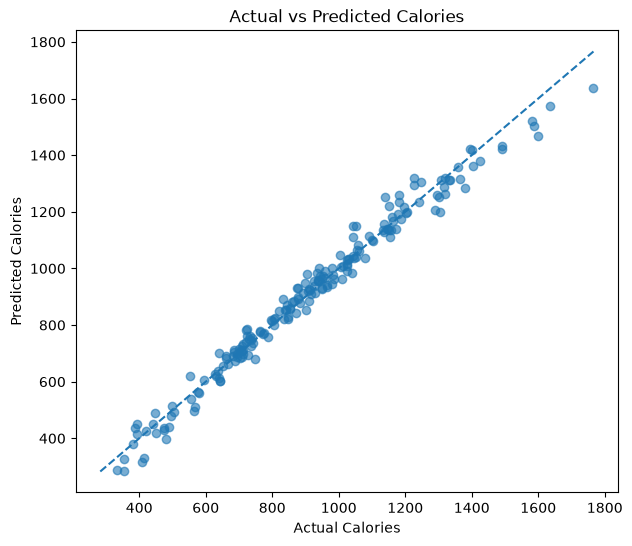

In [24]:
plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    linear_predictions,
    alpha=0.6
)

minimum_value = min(y_test.min(), linear_predictions.min())
maximum_value = max(y_test.max(), linear_predictions.max())

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--"
)

plt.title("Actual vs Predicted Calories")
plt.xlabel("Actual Calories")
plt.ylabel("Predicted Calories")

plt.show()

### Finding

Most predictions are located close to the reference line, indicating that the Linear Regression model predicts calories burned accurately.

The model performs especially well for the middle range of calorie values. However, some high-calorie workouts are slightly underestimated.

## Residual Analysis

Residuals show the difference between actual and predicted calorie values.

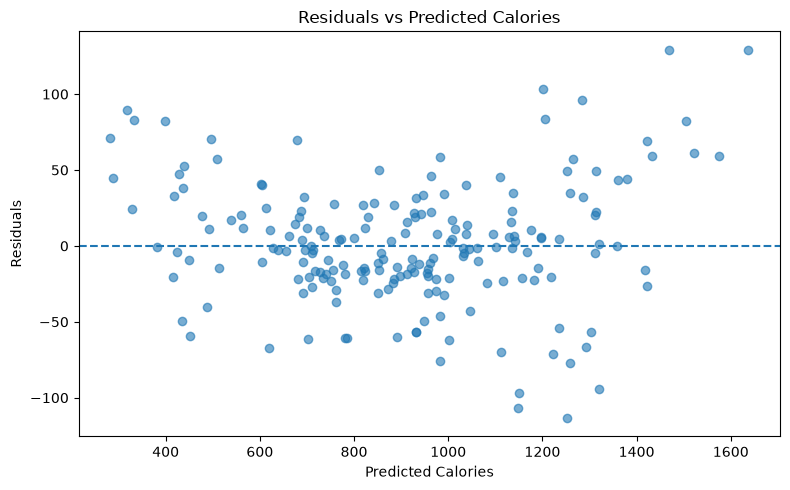

In [25]:
residuals = y_test - linear_predictions

plt.figure(figsize=(8, 5))

plt.scatter(
    linear_predictions,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Residuals vs Predicted Calories")
plt.xlabel("Predicted Calories")
plt.ylabel("Residuals")
plt.tight_layout()

plt.show()

### Finding

Most residuals are located around zero, which indicates that the Linear Regression model performs well overall.

However, the errors become more widely distributed for higher predicted calorie values. The model also slightly overestimates some middle-range values and underestimates some high-calorie workouts.

## Feature Importance

The coefficients of the Linear Regression model show how each feature influences the calorie prediction.

In [26]:
feature_names = (
    linear_model
    .named_steps["data_preparing"]
    .get_feature_names_out()
)

coefficients = (
    linear_model
    .named_steps["model"]
    .coef_
)

coefficient_table = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coefficient_table["Absolute_Coefficient"] = (
    coefficient_table["Coefficient"].abs()
)

coefficient_table = coefficient_table.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

coefficient_table

,Feature,Coefficient,Absolute_Coefficient
6,numerical__Session_Duration (hours),240.019892,240.019892
4,numerical__Avg_BPM,88.655370,88.655370
12,categorical__Gender_Male,82.597321,82.597321
0,numerical__Age,-40.294028,40.294028
11,numerical__BMI,22.053250,22.053250
1,numerical__Weight (kg),-21.214677,21.214677
2,numerical__Height (m),13.952240,13.952240
15,categorical__Workout_Type_Yoga,-8.347546,8.347546
5,numerical__Resting_BPM,4.455264,4.455264
13,categorical__Workout_Type_HIIT,-4.227654,4.227654


### Most Important Features

This chart shows the ten features with the largest Linear Regression coefficients.

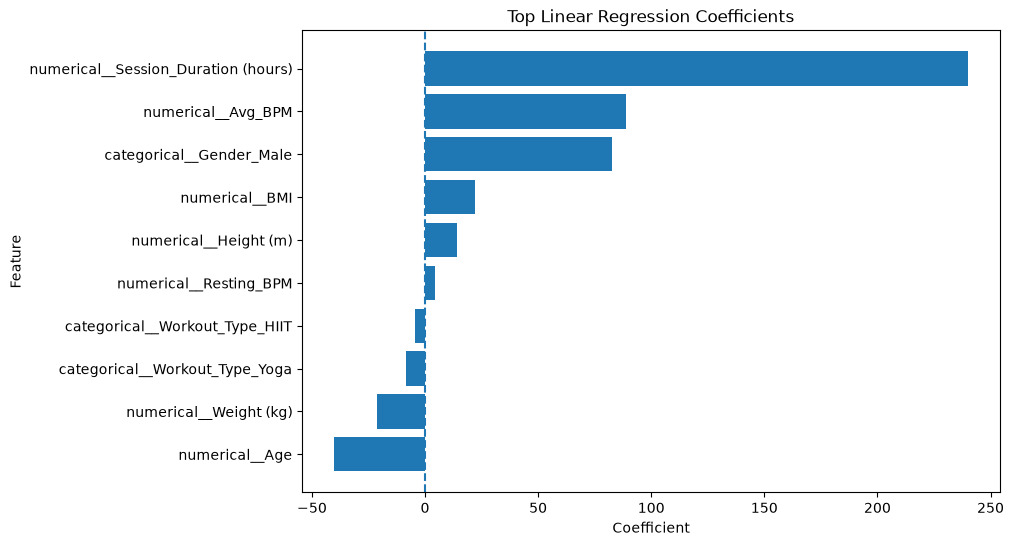

In [29]:
top_coefficients = (
    coefficient_table
    .head(10)
    .sort_values(by="Coefficient")
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_coefficients["Feature"],
    top_coefficients["Coefficient"]
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.title("Top Linear Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")


plt.show()

### Finding

Session duration is the most influential feature in the Linear Regression model, followed by average heart rate.

Gender also contributes to the prediction, while workout type has a relatively small effect after accounting for the other features.

Age has a negative coefficient in this model. These coefficients describe the model's relationships and should not be interpreted as direct causal effects.

## Example Prediction

The trained Linear Regression model is used to predict calories burned for a hypothetical workout.

In [28]:
new_workout = pd.DataFrame({
    "Age": [30],
    "Gender": ["Male"],
    "Weight (kg)": [80],
    "Height (m)": [1.80],
    "Max_BPM": [190],
    "Avg_BPM": [150],
    "Resting_BPM": [65],
    "Session_Duration (hours)": [1.2],
    "Workout_Type": ["HIIT"],
    "Fat_Percentage": [18],
    "Water_Intake (liters)": [2.5],
    "Workout_Frequency (days/week)": [4],
    "Experience_Level": [2],
    "BMI": [24.7]
})

predicted_calories = linear_model.predict(new_workout)[0]

print(f"Predicted calories burned: {predicted_calories:.0f}")

Predicted calories burned: 982


### Example Prediction Result

For the hypothetical workout profile, the Linear Regression model predicts approximately 982 calories burned.

This value is a model estimate based on patterns in the dataset and should not be interpreted as a medical or physiological measurement.

## Conclusion

Two regression models were trained and evaluated:

- Linear Regression
- Random Forest Regressor

Linear Regression performed better than Random Forest.

### Best Model Results

- MAE: approximately 30 calories
- RMSE: approximately 41 calories
- R²: approximately 0.98

The model explains approximately 98% of the variation in calories burned.

Session duration was the most influential feature, followed by average heart rate. The model performed well overall, although prediction errors were slightly larger for some high-calorie workouts.

